## Import Required Libraries

Import the required Python libraries for data analysis and visualization.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Berka Datasets

Load all Berka datasets into pandas DataFrames to prepare them for analysis.

In [45]:
district = pd.read_csv("district.csv", sep=";")
account = pd.read_csv("account.csv", sep=";")
client = pd.read_csv("client.csv", sep=";")
disp = pd.read_csv("disp.csv", sep=";")
card = pd.read_csv("card.csv", sep=";")
loan = pd.read_csv("loan.csv", sep=";")
orders = pd.read_csv("order.csv", sep=";")
trans = pd.read_csv("trans.csv", sep=";", low_memory=False)

## Prepare Analysis Dates

Convert the date fields to datetime format so they can be used for time-based analysis.

In [46]:
account['date'] = pd.to_datetime(account['date'].astype(str), format='%y%m%d')
loan['date'] = pd.to_datetime(loan['date'].astype(str), format='%y%m%d')
trans['date'] = pd.to_datetime(trans['date'].astype(str), format='%y%m%d')
card['issued'] = pd.to_datetime(card['issued'], format='%y%m%d %H:%M:%S')

## Prepare Transaction Data

Create the basic transaction fields required for customer activity and financial behavior analysis.

In [47]:
trans['month'] = trans['date'].dt.to_period('M')
trans['year'] = trans['date'].dt.year

# MODULE 1 — Customer Value & Cards

Analyze customer transaction behavior using RFM analysis to measure customer value and activity. 
Then segment customers based on their RFM scores and compare these segments with card adoption and card tiers.

## Q1 — RFM Analysis

Calculate customer-level Recency, Frequency, and Monetary values to measure how recently customers transact, how frequently they transact, and the total observed inflows associated with their transactions.

→ Required data selection  
→ Merge  
→ Reference date preparation  
→ Recency calculation  
→ Frequency calculation  
→ Monetary calculation  
→ RFM table

In [48]:
# Q1 — RFM Calculation

# Step 1: Select the required columns from customer, disposition, and transaction data
c = client[['client_id']]
d = disp[['client_id', 'account_id']]
t = trans[['account_id', 'date', 'amount', 'type']].copy()


# Step 2: Merge customer data with account relationships and transactions
rfm = c.merge(d, on='client_id', how='inner')
rfm = rfm.merge(t, on='account_id', how='inner')


# Step 3: Set the reference date as the latest transaction date in the dataset
ref_date = rfm['date'].max()


# Step 4: Calculate Recency, Frequency, and Monetary metrics at customer level
rfm = rfm.groupby('client_id').agg(
    recency=('date', lambda x: (ref_date - x.max()).days),
    frequency=('date', 'count'),
    monetary=('amount', lambda x: rfm.loc[x.index]
              .loc[rfm.loc[x.index, 'type'] == 'PRIJEM', 'amount'].sum())
).reset_index()


# Step 5: Display the customer-level RFM table
rfm.head(5)


,client_id,recency,frequency,monetary
0,1,0,239,194320.5
1,2,0,478,1597053.5
2,3,0,478,1597053.5
3,4,0,117,173059.0
4,5,0,117,173059.0


## Q2 — RFM Scoring & Segmentation

Convert the Recency, Frequency, and Monetary values into scores and classify customers into Low, Medium, and High RFM segments based on their overall customer value.

→ Create percentile ranks  
→ Convert ranks into RFM scores  
→ Calculate overall RFM score  
→ Create customer segments  
→ Remove temporary ranking columns  
→ Final RFM segmentation table

In [49]:
# Q2 — RFM Scoring & Segmentation

# Step 1: Create percentile ranks for Recency, Frequency, and Monetary
rfm['r_rank'] = rfm['recency'].rank(method='first')
rfm['f_rank'] = rfm['frequency'].rank(method='first')
rfm['m_rank'] = rfm['monetary'].rank(method='first')


# Step 2: Convert the percentile ranks into RFM scores
# Recency is reversed: lower recency = better score
rfm['r_score'] = pd.qcut(
    rfm['r_rank'],
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm['f_score'] = pd.qcut(
    rfm['f_rank'],
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm['m_score'] = pd.qcut(
    rfm['m_rank'],
    4,
    labels=[1, 2, 3, 4]
).astype(int)


# Step 3: Calculate the overall RFM score
rfm['rfm_score'] = (
    rfm['r_score'] +
    rfm['f_score'] +
    rfm['m_score']
)


# Step 4: Create customer segments
rfm['segment'] = pd.cut(
    rfm['rfm_score'],
    bins=[0, 6, 9, 12],
    labels=['Low', 'Medium', 'High']
)


# Step 5: Remove temporary ranking columns
rfm = rfm.drop(columns=['r_rank', 'f_rank', 'm_rank'])


# Step 6: Display the final RFM scoring and segmentation table
rfm.head()

,client_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,1,0,239,194320.5,4,3,1,8,Medium
1,2,0,478,1597053.5,4,4,4,12,High
2,3,0,478,1597053.5,4,4,4,12,High
3,4,0,117,173059.0,4,1,1,6,Low
4,5,0,117,173059.0,4,1,1,6,Low


## Q3 — RFM Segment vs Card Tier

Compare RFM customer segments with card adoption and card tiers to understand how customer value is distributed across different card categories.

→ Select customer and card data  
→ Merge customer with card information  
→ Identify card tiers  
→ Handle customers without cards  
→ Combine card information with RFM segments  
→ Create summary table  
→ Create visualization

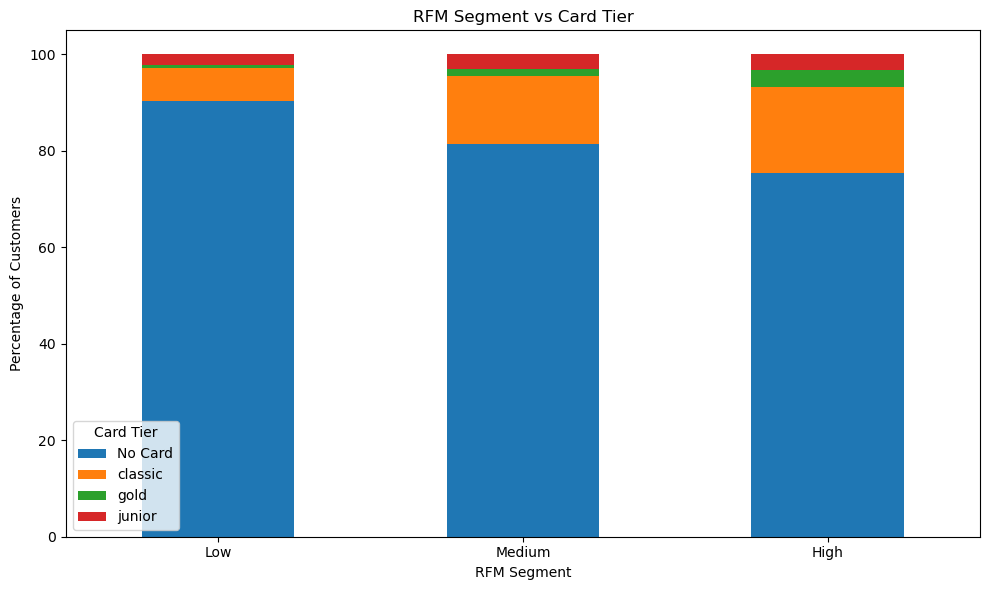

In [50]:
# Q3 — RFM Segment vs Card Tier

# Step 1: Select the required card and customer columns
c = client[['client_id']]
d = disp[['client_id', 'disp_id']]
ca = card[['disp_id', 'type']].copy()


# Step 2: Connect customers with their cards
cards = c.merge(d, on='client_id', how='left')
cards = cards.merge(ca, on='disp_id', how='left')


# Step 3: Keep one card tier per customer
cards = cards[['client_id', 'type']].drop_duplicates()


# Step 4: Add customers without a card
cards['type'] = cards['type'].fillna('No Card')


# Step 5: Combine card information with RFM segments
q3 = rfm[['client_id', 'segment']].merge(
    cards,
    on='client_id',
    how='left'
)


# Step 6: Create the RFM segment vs card tier summary
q3_summary = pd.crosstab(
    q3['segment'],
    q3['type']
)


# Step 7: Display the comparison
q3_summary

# Q3 — RFM Segment vs Card Tier Visualization

# Step 1: Calculate the percentage distribution of card tiers
q3_pct = q3_summary.div(
    q3_summary.sum(axis=1),
    axis=0
) * 100


# Step 2: Create the stacked bar chart
q3_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('RFM Segment vs Card Tier')
plt.xlabel('RFM Segment')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Card Tier')
plt.tight_layout()
plt.show()

# MODULE 2 — Balance Behavior & Liquidity

Analyze account-level balance behavior and liquidity patterns to understand how customers' account balances move, how standing-order activity relates to balances, and how stable their available funds are over time.

The module focuses on observed transaction balances and inflows/outflows rather than treating account activity as confirmed income or financial health.

## Q4 — Standing Orders vs Balance Behavior

Compare standing-order activity with account balances to understand whether accounts with higher recurring payment activity show different observed balance levels.

→ Select required account, standing-order, and transaction data  
→ Aggregate standing-order amounts by account  
→ Calculate the average transaction balance for each account  
→ Merge standing-order and balance information  
→ Group accounts based on standing-order activity  
→ Compare average balances across groups  
→ Create the final summary table

In [51]:
# Q4 — Standing Orders vs Balance Behavior

# Step 1: Select the required columns
o = orders[['account_id', 'amount']].copy()
t = trans[['account_id', 'balance']].copy()


# Step 2: Calculate total standing-order amount for each account
order_summary = (
    o.groupby('account_id')['amount']
    .sum()
    .reset_index()
    .rename(columns={'amount': 'total_order_amount'})
)


# Step 3: Calculate average transaction balance for each account
balance_summary = (
    t.groupby('account_id')['balance']
    .mean()
    .reset_index()
    .rename(columns={'balance': 'average_balance'})
)


# Step 4: Combine standing-order and balance information
q4 = order_summary.merge(
    balance_summary,
    on='account_id',
    how='inner'
)


# Step 5: Create standing-order activity groups
q4['order_group'] = pd.qcut(
    q4['total_order_amount'],
    3,
    labels=['Low', 'Medium', 'High']
)


# Step 6: Compare average balances across groups
q4_summary = (
    q4.groupby('order_group', observed=True)
    .agg(
        account_count=('account_id', 'count'),
        average_order_amount=('total_order_amount', 'mean'),
        average_balance=('average_balance', 'mean')
    )
    .reset_index()
)


# Step 7: Display the comparison
q4_summary

,order_group,account_count,average_order_amount,average_balance
0,Low,1253,2323.626975,26557.847002
1,Medium,1252,4621.337220,38450.453787
2,High,1253,10001.256824,43216.976222


## Q4 Visualization — Standing-Order Activity vs Balance Behavior

Visualize the distribution of observed account balances across different levels of standing-order activity to understand how balance levels and variability differ between account groups.

→ Compare observed account balances across Low, Medium, and High standing-order activity groups  
→ Examine the distribution of account balances within each group  
→ Identify differences in median balance and balance variability  
→ Observe whether higher standing-order activity is associated with different balance patterns  
→ Interpret the results as observed account-level patterns rather than causal relationships

<Figure size 900x600 with 0 Axes>

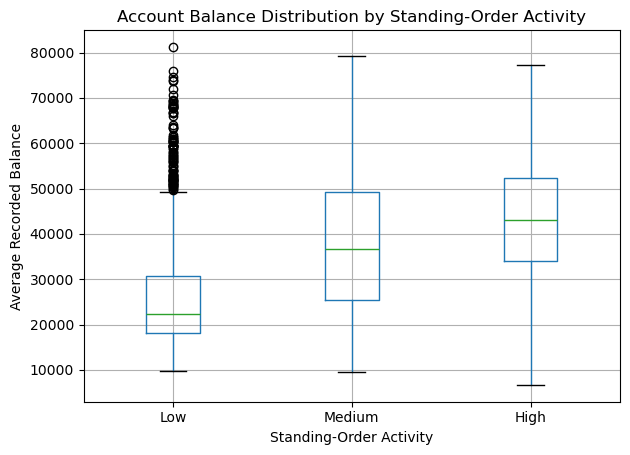

In [71]:
# Q4 Visualization — Standing-Order Activity vs Balance Behavior

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

q4.boxplot(
    column='average_balance',
    by='order_group'
)

plt.title('Account Balance Distribution by Standing-Order Activity')
plt.suptitle('')
plt.xlabel('Standing-Order Activity')
plt.ylabel('Average Recorded Balance')

plt.tight_layout()
plt.show()

## Q5 — Drawdown & Liquidity Stability

Measure how often accounts experience negative balances and assess the level of observed liquidity pressure based on transaction-level account balances.

→ Select required account and transaction data
→ Identify negative balance transactions
→ Calculate negative balance count for each account
→ Calculate total transaction count for each account
→ Calculate negative balance percentage
→ Classify accounts by liquidity pressure
→ Create the final liquidity stability summary

In [52]:
# Q5 — Drawdown & Liquidity Stability

# Step 1: Select the required transaction columns
t = trans[['account_id', 'balance']].copy()


# Step 2: Calculate total transactions for each account
total_trans = (
    t.groupby('account_id')
    .size()
    .reset_index(name='total_transactions')
)


# Step 3: Identify transactions with negative balances
t['negative_balance'] = t['balance'] < 0


# Step 4: Calculate negative balance count for each account
negative_trans = (
    t.groupby('account_id')['negative_balance']
    .sum()
    .reset_index(name='negative_balance_count')
)


# Step 5: Combine total and negative transaction counts
q5 = total_trans.merge(
    negative_trans,
    on='account_id',
    how='left'
)


# Step 6: Calculate negative balance percentage
q5['negative_balance_pct'] = (
    q5['negative_balance_count'] /
    q5['total_transactions']
) * 100


# Step 7: Classify accounts by observed liquidity pressure
q5['liquidity_pressure'] = pd.cut(
    q5['negative_balance_pct'],
    bins=[-0.01, 0, 5, 100],
    labels=['No Negative Balance', 'Low', 'High']
)


# Step 8: Display the final account-level result
q5.head(5)

,account_id,total_transactions,negative_balance_count,negative_balance_pct,liquidity_pressure
0,1,239,0,0.0,No Negative Balance
1,2,478,0,0.0,No Negative Balance
2,3,117,0,0.0,No Negative Balance
3,4,186,0,0.0,No Negative Balance
4,5,84,0,0.0,No Negative Balance


## Q5 Visualization — Liquidity Pressure Distribution

Visualize the number of accounts across different liquidity-pressure categories to understand how frequently negative recorded balances occur across the account portfolio.

→ Count accounts with no recorded negative balance  
→ Count accounts with low liquidity pressure  
→ Count accounts with high liquidity pressure  
→ Compare the size of each liquidity-pressure group  
→ Identify the proportion of accounts requiring closer liquidity monitoring

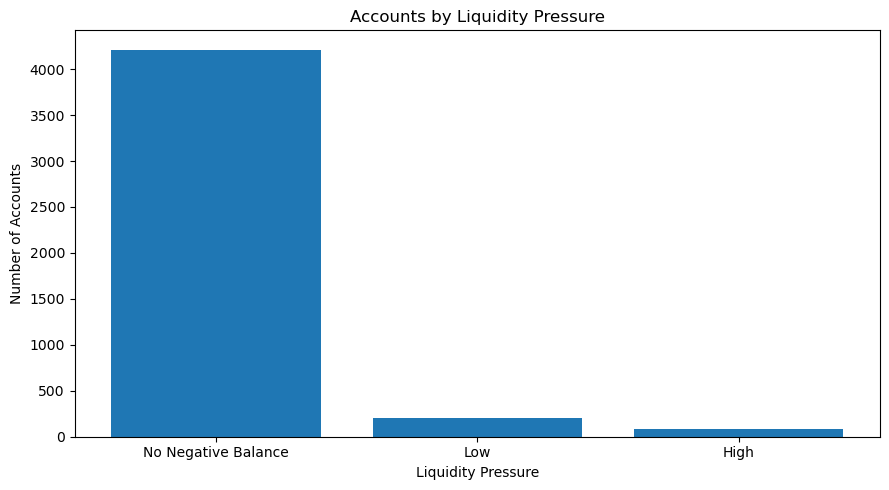

In [72]:
# Q5 Visualization — Liquidity Pressure Distribution

import matplotlib.pyplot as plt

q5_summary = (
    q5['liquidity_pressure']
    .value_counts()
    .reindex(
        ['No Negative Balance', 'Low', 'High'],
        fill_value=0
    )
)

plt.figure(figsize=(9, 5))

plt.bar(
    q5_summary.index,
    q5_summary.values
)

plt.title('Accounts by Liquidity Pressure')
plt.xlabel('Liquidity Pressure')
plt.ylabel('Number of Accounts')

plt.tight_layout()
plt.show()

## Q6 — Moving Balance Trajectory

Analyze how account balances change over time using a moving average to identify longer-term balance trends and short-term fluctuations.

→ Select required transaction data  
→ Convert transaction dates into a usable datetime format  
→ Calculate the moving average balance for each account  
→ Compare recorded balances with the moving average  
→ Identify periods of increasing or decreasing balance trends  
→ Examine short-term balance fluctuations around the moving average  
→ Create the final account-level balance trajectory summary

In [53]:
# Q6 — Moving Balance Trajectory

# Step 1: Select required transaction columns
t = trans[['account_id', 'date', 'balance']].copy()


# Step 2: Sort transactions by account and date
t = t.sort_values(['account_id', 'date'])


# Step 3: Calculate 30-day moving average balance for each account
t['moving_avg_balance_30d'] = (
    t.set_index('date')
     .groupby('account_id')['balance']
     .rolling('30D')
     .mean()
     .reset_index(level=0, drop=True)
     .values
)


# Step 4: Calculate the difference between actual balance
# and the 30-day moving average
t['balance_vs_moving_avg'] = (
    t['balance'] - t['moving_avg_balance_30d']
)


# Step 5: Create the final account-level summary
q6_summary = (
    t.groupby('account_id')
     .agg(
         total_transactions=('balance', 'size'),
         average_balance=('balance', 'mean'),
         average_30d_moving_balance=('moving_avg_balance_30d', 'mean'),
         average_balance_deviation=('balance_vs_moving_avg', 'mean'),
         minimum_balance=('balance', 'min'),
         maximum_balance=('balance', 'max')
     )
     .reset_index()
)


# Step 6: Display the final summary
q6_summary.head()

,account_id,total_transactions,average_balance,average_30d_moving_balance,average_balance_deviation,minimum_balance,maximum_balance
0,1,239,15994.008368,16056.974563,-62.966194,1000.0,30414.8
1,2,478,36540.704393,36878.882237,-338.177844,1100.0,69302.0
2,3,117,26973.506838,26403.213055,570.293783,1000.0,53446.5
3,4,186,21753.446237,21928.195864,-174.749628,800.0,34870.0
4,5,84,25090.069048,25134.455997,-44.386950,600.0,32036.2


## Q6 Visualization — 30-Day Moving Balance Trajectory

Visualize the recorded balance and its 30-day moving average over time for an individual account to identify short-term fluctuations and the underlying balance pattern.

→ Select transaction history for an individual account  
→ Sort transactions chronologically  
→ Plot the recorded account balance over time  
→ Plot the 30-day moving average balance  
→ Compare short-term balance movements with the smoothed trend  
→ Identify periods where the recorded balance moves above or below its recent average  
→ Use the moving average to distinguish short-term fluctuations from the broader balance pattern

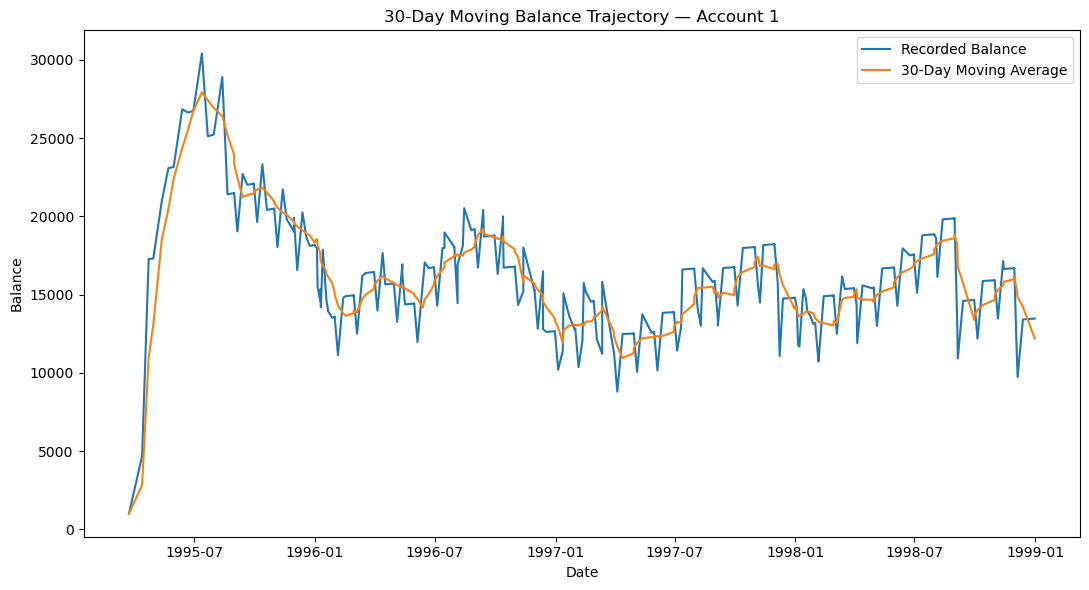

In [73]:
# Q6 Visualization — 30-Day Moving Balance Trajectory

import matplotlib.pyplot as plt

# Step 1: Select one account for trajectory visualization
account_id = 1

q6_plot = trans[
    trans['account_id'] == account_id
][['account_id', 'date', 'balance']].copy()

# Step 2: Sort transactions chronologically
q6_plot = q6_plot.sort_values('date')

# Step 3: Calculate the 30-day moving average
q6_plot['moving_avg_balance_30d'] = (
    q6_plot
    .set_index('date')['balance']
    .rolling('30D')
    .mean()
    .values
)

# Step 4: Plot actual balance
plt.figure(figsize=(11, 6))

plt.plot(
    q6_plot['date'],
    q6_plot['balance'],
    label='Recorded Balance'
)

# Step 5: Plot 30-day moving average
plt.plot(
    q6_plot['date'],
    q6_plot['moving_avg_balance_30d'],
    label='30-Day Moving Average'
)

# Step 6: Add chart labels
plt.title(f'30-Day Moving Balance Trajectory — Account {account_id}')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.legend()

plt.tight_layout()
plt.show()

# MODULE 3 — Credit Risk Drivers

Analyze loan portfolio characteristics and repayment patterns to understand the key factors associated with observed credit risk.

The module focuses on loan exposure, repayment status, debt-service burden, and loan characteristics to identify patterns that may be relevant for credit-risk analysis.

## Q7 — Loan Portfolio & Repayment Status

Analyze the loan portfolio by repayment status to understand loan distribution, total exposure, and the concentration of loans across different repayment outcomes.

→ Select required loan data  
→ Calculate total number of loans  
→ Calculate total loan amount  
→ Group loans by repayment status  
→ Calculate loan count and loan amount for each status  
→ Calculate portfolio share by loan count  
→ Calculate portfolio share by loan amount  
→ Create the final loan portfolio and repayment status summary

In [54]:
# Q7 — Loan Portfolio & Repayment Status

# Step 1: Select required loan data
l = loan[['loan_id', 'amount', 'status']].copy()


# Step 2: Calculate overall loan portfolio metrics
total_loans = l['loan_id'].nunique()
total_loan_amount = l['amount'].sum()


# Step 3: Group loans by repayment status
q7 = (
    l.groupby('status')
     .agg(
         loan_count=('loan_id', 'nunique'),
         total_loan_amount=('amount', 'sum')
     )
     .reset_index()
)


# Step 4: Calculate portfolio share by loan count
q7['loan_count_pct'] = (
    q7['loan_count'] /
    total_loans
) * 100


# Step 5: Calculate portfolio share by loan amount
q7['loan_amount_pct'] = (
    q7['total_loan_amount'] /
    total_loan_amount
) * 100


# Step 6: Add overall portfolio totals
q7['total_loans'] = total_loans
q7['total_portfolio_amount'] = total_loan_amount


# Step 7: Arrange columns
q7 = q7[
    [
        'status',
        'loan_count',
        'loan_count_pct',
        'total_loan_amount',
        'loan_amount_pct',
        'total_loans',
        'total_portfolio_amount'
    ]
]


# Step 8: Sort by loan count
q7 = q7.sort_values(
    'loan_count',
    ascending=False
).reset_index(drop=True)


# Step 9: Display final summary
q7

,status,loan_count,loan_count_pct,total_loan_amount,loan_amount_pct,total_loans,total_portfolio_amount
0,C,403,59.090909,69078372,66.896386,682,103261740
1,A,203,29.765396,18603216,18.015594,682,103261740
2,D,45,6.598240,11217804,10.863466,682,103261740
3,B,31,4.545455,4362348,4.224554,682,103261740


## Q7 Visualization — Loan Exposure by Repayment  Status

Visualize the distribution of total loan exposure across repayment statuses to identify which status represents the largest share of the bank's outstanding loan portfolio.

→ Compare total loan exposure across repayment statuses  
→ Identify the status with the highest loan exposure  
→ Highlight differences in portfolio concentration  

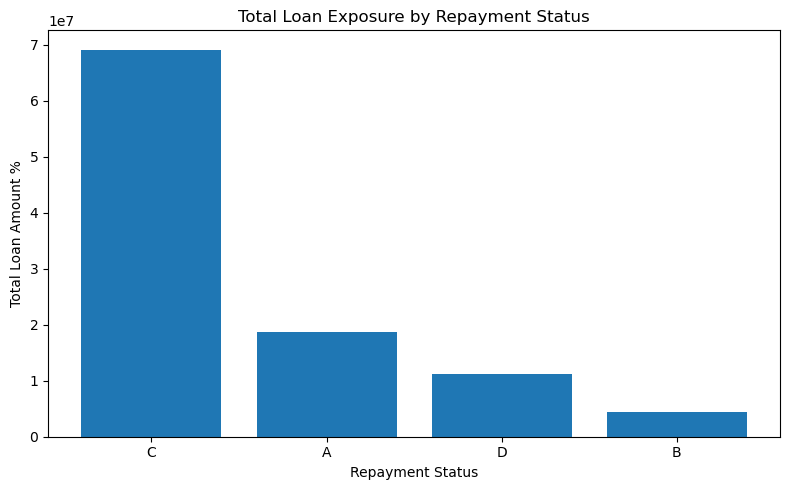

In [55]:
# Q7 Visualization — Loan Exposure by Repayment Status

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    q7['status'],
    q7['total_loan_amount']
)

plt.title('Total Loan Exposure by Repayment Status')
plt.xlabel('Repayment Status')
plt.ylabel('Total Loan Amount %')

plt.tight_layout()
plt.show()

## Q8 — Debt-Service Burden & Repayment Pressure

Measure the monthly debt-service burden of loans by comparing scheduled loan payments with the account's observed average monthly inflows to identify accounts with relatively high repayment pressure.

→ Select required loan and transaction data  
→ Convert transaction dates into a usable datetime format  
→ Calculate monthly transaction inflows for each account  
→ Calculate average monthly inflow for each account  
→ Match loan payments with account-level inflow information  
→ Calculate the debt-service burden ratio  
→ Identify loans with relatively high repayment burden  
→ Create the final debt-service burden summary

In [56]:
# Q8 — Debt-Service Burden & Repayment Pressure

# Step 1: Select required loan data
l = loan[['loan_id', 'account_id', 'payments', 'status']].copy()

# Step 2: Select required transaction data
t = trans[['account_id', 'date', 'type', 'amount']].copy()

# Step 3: Keep only observed inflow transactions
inflows = t[t['type'] == 'PRIJEM'].copy()

# Step 4: Convert transaction date into month
inflows['month'] = inflows['date'].dt.to_period('M')

# Step 5: Calculate total observed inflow for each account and month
monthly_inflow = (
    inflows.groupby(['account_id', 'month'])['amount']
    .sum()
    .reset_index(name='monthly_inflow')
)

# Step 6: Calculate average monthly observed inflow for each account
avg_monthly_inflow = (
    monthly_inflow.groupby('account_id')['monthly_inflow']
    .mean()
    .reset_index(name='average_monthly_inflow')
)

# Step 7: Combine loan payments with account-level inflow information
q8 = l.merge(
    avg_monthly_inflow,
    on='account_id',
    how='left'
)

# Step 8: Calculate debt-service burden
q8['debt_service_burden_pct'] = (
    q8['payments'] /
    q8['average_monthly_inflow']
) * 100

# Step 9: Arrange final columns
q8 = q8[
    [
        'loan_id',
        'account_id',
        'status',
        'payments',
        'average_monthly_inflow',
        'debt_service_burden_pct'
    ]
]

# Step 10: Display the final summary
q8

,loan_id,account_id,status,payments,average_monthly_inflow,debt_service_burden_pct
0,5314,1787,B,8033.0,31172.686364,25.769354
1,5316,1801,A,4610.0,34122.869014,13.510001
2,6863,9188,A,2118.0,14059.285915,15.064776
3,5325,1843,A,2939.0,19416.751389,15.136415
4,7240,11013,A,4579.0,45502.926761,10.063089
...,...,...,...,...,...,...
677,4989,105,C,7348.0,14193.927778,51.768616
678,5221,1284,C,4376.0,31336.788889,13.964417
679,6402,6922,C,5812.0,37674.360000,15.426938
680,5346,1928,C,2318.0,17479.713636,13.261087


## Q8 Visualization — Debt-Service Burden Distribution

Visualize the distribution of debt-service burden across loans to identify the concentration of loans with relatively low or high repayment pressure compared with observed average monthly inflows.

→ Examine the distribution of debt-service burden percentages  
→ Identify the concentration of loans across different burden levels  
→ Highlight loans with relatively high observed repayment pressure

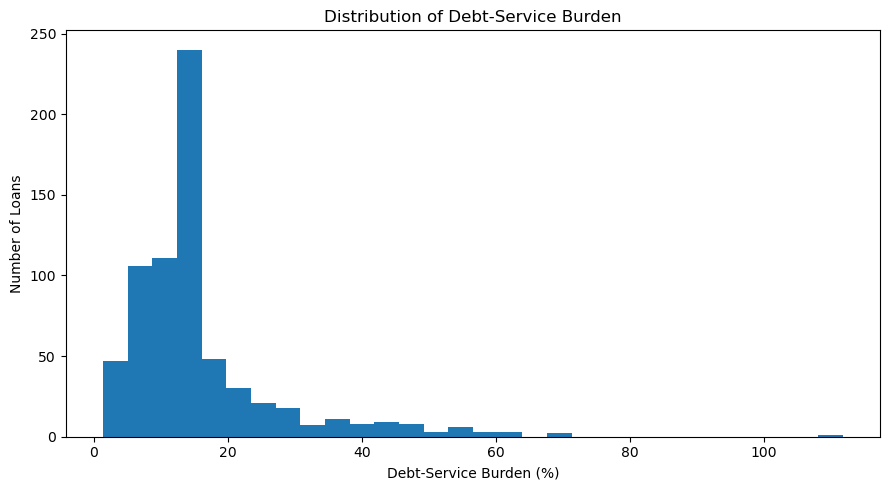

In [57]:
# Q8 Visualization — Debt-Service Burden Distribution

import matplotlib.pyplot as plt

# Remove missing and infinite burden values
burden = q8['debt_service_burden_pct'].replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

plt.figure(figsize=(9, 5))

plt.hist(
    burden,
    bins=30
)

plt.title('Distribution of Debt-Service Burden')
plt.xlabel('Debt-Service Burden (%)')
plt.ylabel('Number of Loans')

plt.tight_layout()
plt.show()

## Q9 — Loan Risk by Term & Amount

Analyze the relationship between loan amount and loan duration to identify patterns in loan size and repayment terms across different repayment statuses.

→ Select required loan data  
→ Compare loan amount with loan duration  
→ Group loans by repayment status  
→ Calculate loan count and average loan amount for each status  
→ Calculate average loan duration for each status  
→ Create the final loan term and amount summary

In [58]:
# Q9 — Loan Risk by Term & Amount

# Step 1: Select required loan data
l = loan[['loan_id', 'amount', 'duration', 'status']].copy()

# Step 2: Create summary by repayment status
q9_summary = (
    l.groupby('status')
     .agg(
         loan_count=('loan_id', 'count'),
         average_loan_amount=('amount', 'mean'),
         average_duration=('duration', 'mean')
     )
     .reset_index()
)

# Step 3: Display the final summary
q9_summary

,status,loan_count,average_loan_amount,average_duration
0,A,203,91641.458128,22.226601
1,B,31,140720.903226,25.548387
2,C,403,171410.352357,43.444169
3,D,45,249284.533333,46.133333


## Q9 Visualization — Loan Amount vs Duration

Visualize the relationship between loan amount and loan duration to identify whether larger loans tend to have longer repayment periods.

→ Compare loan amount with loan duration  
→ Identify visible patterns in loan size and repayment term  
→ Observe the overall relationship between loan amount and duration

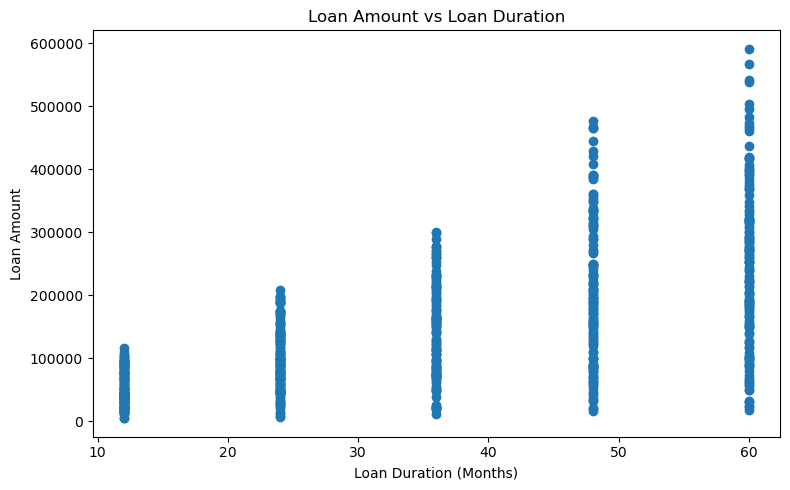

In [59]:
# Q9 Visualization — Loan Amount vs Duration

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    l['duration'],
    l['amount']
)

plt.title('Loan Amount vs Loan Duration')
plt.xlabel('Loan Duration (Months)')
plt.ylabel('Loan Amount')

plt.tight_layout()
plt.show()

# MODULE 4 — Geographic Macro-Risk

Analyze whether regional economic conditions are associated with observed loan default patterns and whether higher average salary levels are associated with lower default risk across districts.

The module focuses on district-level macroeconomic indicators such as unemployment, average salary, and crime, and compares them with observed loan repayment outcomes.

The analysis is performed at the district level to identify regional patterns and relationships rather than individual customer-level risk.

The results should be interpreted as observed regional associations and should not be treated as proof of causation.

## Q10 — Regional Loan Risk & Default Rate

Analyze loan repayment outcomes across districts by combining regional economic indicators with observed loan performance to identify differences in regional default rates.

→ Select required district, account, and loan data  
→ Connect accounts with their respective districts  
→ Calculate total loans by district  
→ Identify defaulted loans using repayment status B  
→ Calculate the observed default rate for each district  
→ Add average salary, unemployment, and crime indicators  
→ Create the final district-level regional risk summary

In [60]:
# Q10 — Regional Loan Risk & Default Rate

# Step 1: Select required district data
d = district[['A1', 'A2', 'A11', 'A12', 'A15']].copy()

# Step 2: Rename district columns for easier analysis
d = d.rename(columns={
    'A1': 'district_id',
    'A2': 'district_name',
    'A11': 'average_salary',
    'A12': 'unemployment_rate',
    'A15': 'crime_rate'
})

# Step 3: Select required account data
a = account[['account_id', 'district_id']].copy()

# Step 4: Select required loan data
l = loan[['loan_id', 'account_id', 'status']].copy()

# Step 5: Connect loans with their corresponding districts
loan_district = l.merge(
    a,
    on='account_id',
    how='inner'
)

# Step 6: Calculate total loans and defaulted loans by district
district_loan_summary = (
    loan_district
    .groupby('district_id')
    .agg(
        total_loans=('loan_id', 'nunique'),
        defaulted_loans=('status', lambda x: (x == 'B').sum())
    )
    .reset_index()
)

# Step 7: Calculate the observed default rate
district_loan_summary['default_rate'] = (
    district_loan_summary['defaulted_loans'] /
    district_loan_summary['total_loans']
) * 100

# Step 8: Add regional economic indicators
q10 = district_loan_summary.merge(
    d,
    on='district_id',
    how='left'
)

# Step 9: Arrange the final columns
q10 = q10[
    [
        'district_id',
        'district_name',
        'average_salary',
        'unemployment_rate',
        'crime_rate',
        'total_loans',
        'defaulted_loans',
        'default_rate'
    ]
]

# Step 10: Sort by default rate
q10 = q10.sort_values(
    'default_rate',
    ascending=False
).reset_index(drop=True)

# Step 11: Display the final district-level summary
q10

,district_id,district_name,average_salary,unemployment_rate,crime_rate,total_loans,defaulted_loans,default_rate
0,30,Sokolov,9650,3.38,2985,2,1,50.000000
1,21,Tabor,9104,1.51,2299,7,2,28.571429
2,31,Tachov,8930,3.52,1328,8,2,25.000000
3,24,Karlovy Vary,8991,1.39,5198,8,2,25.000000
4,6,Kutna Hora,8546,2.95,2640,9,2,22.222222
...,...,...,...,...,...,...,...,...
72,40,Teplice,9317,6.49,6949,6,0,0.000000
73,41,Usti nad Labem,9832,3.32,6445,3,0,0.000000
74,42,Havlickuv Brod,8388,2.41,1658,7,0,0.000000
75,43,Hradec Kralove,9425,1.72,4085,5,0,0.000000


## Q10 Visualization — Regional Default Rate

Visualize the observed loan default rate across districts while providing the underlying loan volume to give proper context to the default percentages.

→ Compare observed default rates across districts  
→ Display total loan volume for each district  
→ Identify districts with relatively higher default rates  
→ Consider default rates together with the number of loans  
→ Avoid interpreting high default rates from very small loan populations in isolation

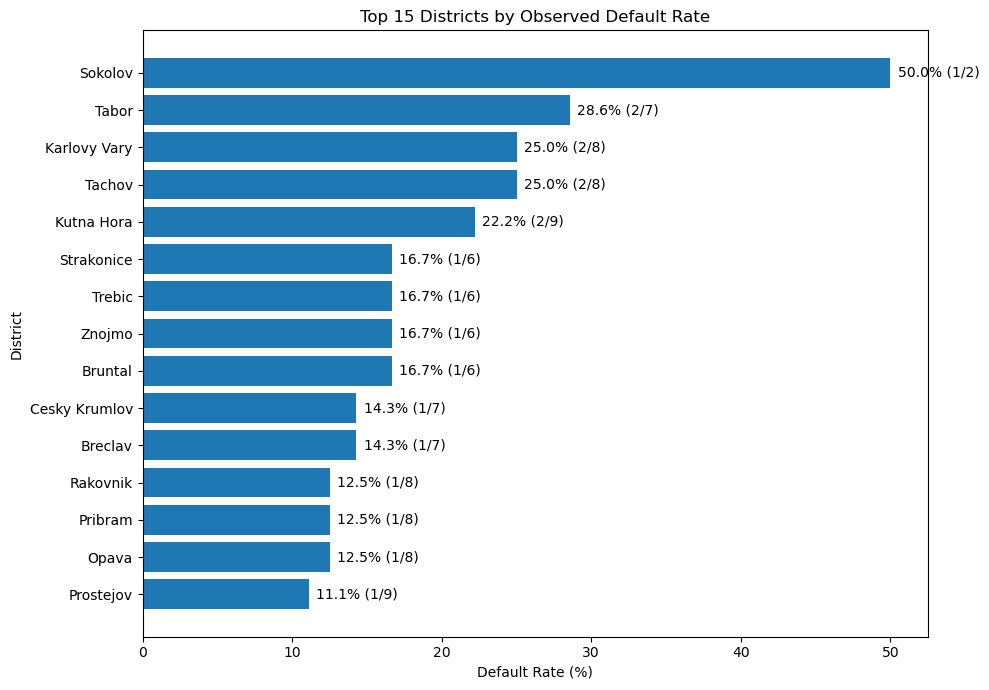

In [61]:
# Q10 Visualization — Regional Default Rate

import matplotlib.pyplot as plt

q10_top = q10.head(15).sort_values(
    'default_rate',
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    q10_top['district_name'],
    q10_top['default_rate']
)

plt.title('Top 15 Districts by Observed Default Rate')
plt.xlabel('Default Rate (%)')
plt.ylabel('District')

# Add loan counts to each bar
for bar, default_rate, total_loans, defaulted_loans in zip(
    bars,
    q10_top['default_rate'],
    q10_top['total_loans'],
    q10_top['defaulted_loans']
):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{default_rate:.1f}% ({defaulted_loans}/{total_loans})',
        va='center'
    )

plt.tight_layout()
plt.show()

## Q11 — Macro-Risk Correlation Analysis

Analyze the relationship between district-level economic indicators and observed loan default rates to identify regional macro-risk patterns.

→ Select the required macroeconomic indicators and observed default rate  
→ Prepare the district-level analysis dataset  
→ Examine average salary, unemployment, and crime alongside default rate  
→ Calculate the correlation between each macroeconomic indicator and default rate  
→ Identify positive and negative associations  
→ Compare the strength and direction of the observed relationships  
→ Interpret the results as regional associations rather than causal relationships  
→ Create the final macro-risk correlation summary

In [67]:
# Q11 — Macro-Risk Correlation Analysis

# Step 1: Select the required macroeconomic indicators
# and observed default rate from Q10
q11 = q10[
    [
        'average_salary',
        'unemployment_rate',
        'crime_rate',
        'default_rate'
    ]
].copy()

# Step 2: Replace source-level '?' values with missing values
q11 = q11.replace('?', np.nan)

# Step 3: Convert the affected columns to numeric
q11['unemployment_rate'] = pd.to_numeric(
    q11['unemployment_rate'],
    errors='coerce'
)

q11['crime_rate'] = pd.to_numeric(
    q11['crime_rate'],
    errors='coerce'
)

# Step 4: Calculate the correlation matrix
q11_correlation = q11.corr()

# Step 5: Display the correlation matrix
q11_correlation

,average_salary,unemployment_rate,crime_rate,default_rate
average_salary,1.000000,-0.063806,0.652244,0.012740
unemployment_rate,-0.063806,1.000000,-0.131764,0.062180
crime_rate,0.652244,-0.131764,1.000000,-0.012416
default_rate,0.012740,0.062180,-0.012416,1.000000


## Q11 Visualization — Macro-Risk Correlation Heatmap


Visualize the correlation between district-level macroeconomic indicators and observed loan default rates to identify the direction and strength of regional relationships.

→ Visualize the correlation matrix using a heatmap  
→ Compare average salary, unemployment, crime, and default rate  
→ Identify positive and negative relationships  
→ Examine the relative strength of the observed correlations  
→ Focus on the relationships between macroeconomic indicators and default rate  
→ Interpret correlations as regional associations rather than causal relationships

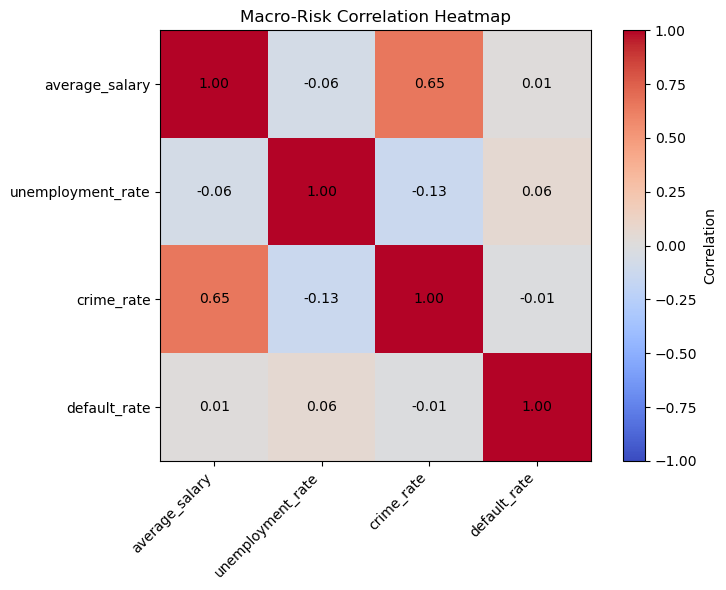

In [68]:
# Q11 Visualization — Macro-Risk Correlation Heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(
    q11_correlation,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(q11_correlation.columns)),
    q11_correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(q11_correlation.index)),
    q11_correlation.index
)

for i in range(len(q11_correlation.index)):
    for j in range(len(q11_correlation.columns)):
        plt.text(
            j,
            i,
            f'{q11_correlation.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Macro-Risk Correlation Heatmap')
plt.tight_layout()
plt.show()

## Q12 — Unemployment vs Default Relationship

Analyze the relationship between district-level unemployment rates and observed loan default rates to examine how these two measures are distributed across districts and identify the overall linear trend.

→ Select district-level unemployment rate and observed default rate  
→ Prepare the district-level analysis dataset  
→ Compare unemployment rate and default rate for each district  
→ Plot each district as an individual observation  
→ Add a regression line to show the overall linear trend  
→ Examine the direction and strength of the observed relationship  
→ Compare the visual pattern with the correlation result from Q11  
→ Interpret the result as a regional association rather than a causal relationship

In [69]:
# Q12 — Unemployment vs Default Relationship

# Step 1: Select required district-level variables from Q10
q12 = q10[
    [
        'district_id',
        'district_name',
        'unemployment_rate',
        'default_rate'
    ]
].copy()

# Step 2: Replace source-level '?' values with missing values
q12 = q12.replace('?', np.nan)

# Step 3: Convert the required columns to numeric
q12['unemployment_rate'] = pd.to_numeric(
    q12['unemployment_rate'],
    errors='coerce'
)

q12['default_rate'] = pd.to_numeric(
    q12['default_rate'],
    errors='coerce'
)

# Step 4: Remove districts with missing values
q12 = q12.dropna(
    subset=['unemployment_rate', 'default_rate']
).reset_index(drop=True)

# Step 5: Display the district-level data
q12

,district_id,district_name,unemployment_rate,default_rate
0,30,Sokolov,3.38,50.000000
1,21,Tabor,1.51,28.571429
2,31,Tachov,3.52,25.000000
3,24,Karlovy Vary,1.39,25.000000
4,6,Kutna Hora,2.95,22.222222
...,...,...,...,...
71,40,Teplice,6.49,0.000000
72,41,Usti nad Labem,3.32,0.000000
73,42,Havlickuv Brod,2.41,0.000000
74,43,Hradec Kralove,1.72,0.000000


## Q12 Visualization — Unemployment vs Default Rate

Visualize the relationship between district-level unemployment rates and observed loan default rates using a scatter plot and regression line.

→ Plot unemployment rate on the x-axis  
→ Plot observed default rate on the y-axis  
→ Represent each district as an individual observation  
→ Add a regression line to show the overall linear trend  
→ Observe whether the districts show an upward, downward, or flat pattern  
→ Compare the visual trend with the correlation result from Q11  
→ Identify whether unemployment shows a meaningful regional relationship with default rate  
→ Avoid interpreting the relationship as causal

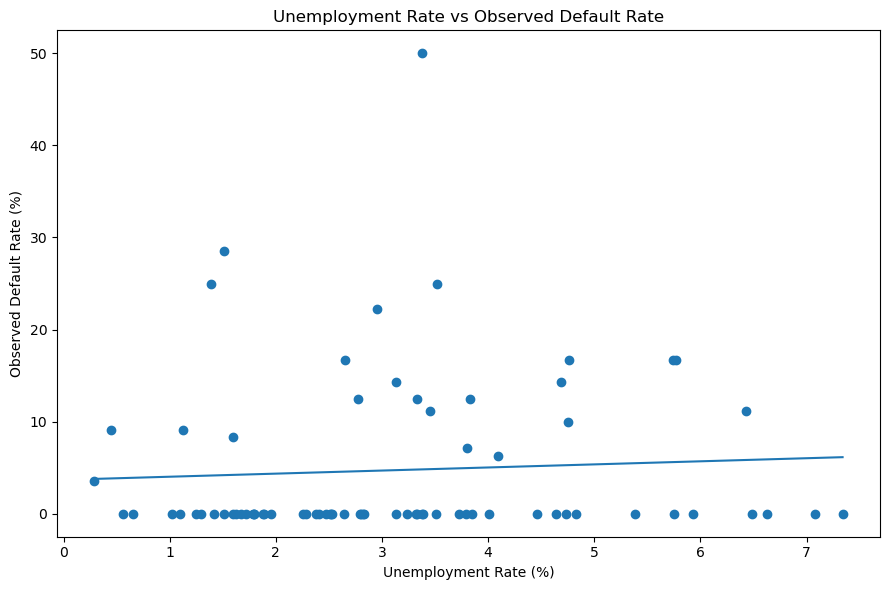

In [70]:
# Q12 Visualization — Unemployment vs Default Rate

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 6))

# Step 1: Scatter plot
plt.scatter(
    q12['unemployment_rate'],
    q12['default_rate']
)

# Step 2: Calculate regression line
x = q12['unemployment_rate']
y = q12['default_rate']

slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

y_line = slope * x_line + intercept

# Step 3: Add regression line
plt.plot(
    x_line,
    y_line
)

# Step 4: Add chart labels
plt.title('Unemployment Rate vs Observed Default Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Observed Default Rate (%)')

plt.tight_layout()
plt.show()

# MODULE 1 — Business Insights

### Customer Value & Card Usage Insights

The customer-value analysis shows that the customer base can be meaningfully differentiated using observed transaction behavior.

- RFM segmentation divided the analyzed customer/account population into three balanced groups: **1,253 Low-value, 1,252 Medium-value, and 1,253 High-value segments**. This provides a practical framework for distinguishing customers based on their observed recency, transaction frequency, and monetary activity.
- The segmentation shows that customer value is not uniform across the portfolio, creating an opportunity for differentiated customer engagement and retention strategies.
- Comparing RFM segments with card tiers provides additional insight into how customers with different observed transaction-value profiles interact with card products.
- Card transaction behavior also differs across card tiers. **Classic cards generated the highest transaction volume and total transaction value**, while Gold cards recorded the **highest average transaction size** among the three observed card tiers.
- Classic cards recorded approximately **159,859 transactions** with total transaction value of about **1.38 billion**, while Gold cards had a higher average transaction size of approximately **9,108** compared with approximately **8,630 for Classic** and **7,637 for Junior**.
- These findings suggest that customer value and card usage can be analyzed together to support more targeted product engagement, retention, and customer-management strategies.

### Business Takeaway

The analysis provides a customer-value framework that can help the bank distinguish high-, medium-, and low-value customer groups and understand their observed card usage patterns. This can support more targeted customer strategies instead of applying the same approach across the entire customer base.

# MODULE 2 — Business Insights

### Balance Behavior & Liquidity Insights

The account-level analysis shows that liquidity behavior varies considerably across the portfolio and should be evaluated using transaction-level balance patterns rather than a single account balance.

- Accounts with different levels of standing-order activity show differences in their observed average transaction balances, indicating that recurring payment commitments can be useful when assessing account-level liquidity behavior.
- The analysis identified **2,999 transaction records with negative recorded balances** across the portfolio. Most of these occurred in **VYDAJ (2,289)** transactions, followed by **PRIJEM (601)** and **VYBER (109)**.
- Negative balances should be treated as an indicator of observed liquidity pressure or an overdraft-like condition rather than automatically being classified as a data error or failed payment.
- The account-level negative-balance analysis allows accounts to be distinguished according to how frequently negative balances occurred during their transaction history.
- The 30-day moving-average analysis provides a smoother view of account balance behavior by reducing the impact of short-term fluctuations.
- For example, Account 1 had an average recorded balance of approximately **15,994**, compared with an average 30-day moving balance of approximately **16,057**, showing that its observed balance was relatively close to its recent moving level.
- Comparing actual balances with their moving averages provides an additional way to identify whether an account's observed balance is generally above, below, or close to its recent balance pattern.

### Business Takeaway

Liquidity risk should not be assessed from a single balance figure. Combining recurring payment activity, negative-balance frequency, and moving balance behavior provides a more complete view of accounts that may require closer liquidity monitoring.

# MODULE 3 — Business Insights

### Credit Risk Insights

The loan portfolio analysis shows that credit exposure is concentrated in a small number of repayment-status categories, while repayment pressure and loan structure vary across the portfolio.

- The portfolio contains **682 loans** with total loan exposure of approximately **103.26 million**.
- Status **C** represents the largest portfolio segment, with **403 loans (59.09%)** and approximately **66.90% of total loan exposure**.
- Status **A** contains **203 loans (29.77%)**, while status **D** represents **45 loans (6.60%)** and status **B** represents **31 loans (4.55%)**.
- Although status B represents a smaller share of the portfolio by loan count, it represents an observed repayment outcome that should receive separate attention in credit-risk monitoring.
- Debt-Service Burden analysis shows that most observed loans have relatively lower scheduled-payment burden compared with the account's observed average monthly inflows, while a smaller group has substantially higher repayment pressure.
- Some loans have scheduled monthly payments that exceed the account's observed average monthly inflows, indicating potentially high repayment pressure and a need for further review.
- Loan size and duration also show a clear portfolio pattern: larger loans generally tend to have longer repayment durations. For example, status C loans averaged approximately **171,410** in loan amount and **43.4 months** in duration, while status D loans averaged approximately **249,285** and **46.1 months** respectively.
- These patterns show that credit exposure should be assessed not only through repayment status, but also through payment burden, loan amount, and repayment duration.

### Business Takeaway

The analysis suggests that effective credit-risk monitoring should combine repayment outcomes with the borrower's observed repayment burden and the structural characteristics of the loan. High payment burden and larger, longer-duration exposures can be useful areas for deeper credit-risk assessment.

# MODULE 4 — Business Insights

### Geographic Macro-Risk Insights

The regional analysis shows that observed loan default rates vary across districts, but district-level macroeconomic indicators do not show strong linear relationships with observed default rates.

- Observed default rates vary considerably across districts. For example, **Sokolov recorded a 50% observed default rate**, but this represented **1 defaulted loan out of only 2 total loans**, demonstrating why default rates should always be considered together with the underlying loan population.
- District-level average salary showed an almost zero correlation with observed default rate (**0.0127**), indicating no meaningful linear relationship in this analysis.
- Unemployment rate showed only a **very weak positive correlation of 0.0622** with observed default rate.
- Crime rate showed an almost zero correlation with observed default rate (**-0.0124**).
- The unemployment-versus-default scatter plot also showed that district-level observations were widely dispersed rather than following a clear upward linear pattern.
- Some districts with relatively low unemployment had comparatively high observed default rates, while some districts with higher unemployment had very low or zero observed default rates.
- Therefore, higher district-level unemployment cannot be treated as a meaningful standalone indicator of higher observed loan default rates in this dataset.
- The results suggest that regional macroeconomic indicators alone do not explain much of the variation in observed loan default rates.

### Business Takeaway

Geographic macroeconomic conditions can provide useful context for regional credit-risk monitoring, but they should not be used as standalone predictors of loan default based on this analysis. A stronger risk assessment would require combining regional indicators with customer-, account-, and loan-level characteristics.